In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pickle
import logic.gwyfile as gwyfile
from logic.gwyfile.objects import GwyContainer, GwyDataField

## Helper functions

In [2]:
def save_obj_to_gwyddion(dataobj,filename,gwytypes=['image']):
    """save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """

    # check for existance of valid object names
    datakeys = list(dataobj.keys())

    # overall object container
    objout = gwy.objects.GwyContainer()

    for dataki,datak in enumerate(sorted(datakeys, key=str.lower)):
        meas = dataobj[datak]

        # check that data is valid
        if not {'coord0_arr','coord1_arr','data'}.issubset(set(meas.keys())):
            continue 

        # check that there is non-trivial data (skip empty measurements)
        if np.sum(meas['data']) == 0.0:
            continue

        # transform data
        #scalefactor = meas['scale_fac']
        coord0 = meas['coord0_arr']
        coord1 = meas['coord1_arr']
        data_si = meas['data'] #* scalefactor

        params = meas['params']
        coord0_start = next(k for k in params.keys() if k.startswith('coord0_start'))
        coord0_stop = next(k for k in params.keys() if k.startswith('coord0_stop'))
        coord1_start = next(k for k in params.keys() if k.startswith('coord1_start'))
        coord1_stop = next(k for k in params.keys() if k.startswith('coord1_stop'))

        xy_units = meas['xy_units']
        z_units = meas['si_units']
        measname = datak + ":" + meas['nice_name']

        # encode to image
        img = gwy.objects.GwyDataField(data=data_si, si_unit_xy=xy_units, si_unit_z=z_units)
        img.xoff = params[coord0_start]
        img.xreal = params[coord0_stop] - params[coord0_start]
        img.yoff = params[coord1_start]
        img.yreal = params[coord1_stop] - params[coord1_start]

        # add to parent object 
        if 'image' in gwytypes: 
            # image types
            basekey = '/' + str(dataki) + '/data'
            objout[basekey + '/title'] = measname
            objout['/' + str(dataki) + '/base/palette'] = 'Sky'
            objout[basekey] = img
            # comment meta data
            if meas['params']:
                d = {key: str(val) for key, val in meas['params'].items()}
                meta = gwy.objects.GwyContainer(d)
                objout['/' + str(dataki) + '/meta'] = meta

    # write out file    
    if objout:
        objout.tofile(filename)

## Define Dataset for analyses

In [5]:
path = 'C:\\Data\\2025\\03\\20250303\\AttoDRY2200_Pi3_SPM\\'
filebeginning = '20250303-1050-15_scan6_CWODMR_autosave_MnTe_L-P11-16_' #here the beginning of the filename, including the date and sample name, is needed
filepath = path + filebeginning

## Load Data from pickel

In [6]:
with open(filepath+'qafm_array_raw.pickle', 'rb') as f:
    qafm_data = pickle.load(f)
with open(filepath+'esr_array_raw.pickle', 'rb') as f:
    esr_data = pickle.load(f)

## Load current data from qafm logic

In [10]:
qafm_data = afm_scanner_logic._qafm_scan_array
esr_data = afm_scanner_logic._esr_scan_array

## Calculate bias field - OOC

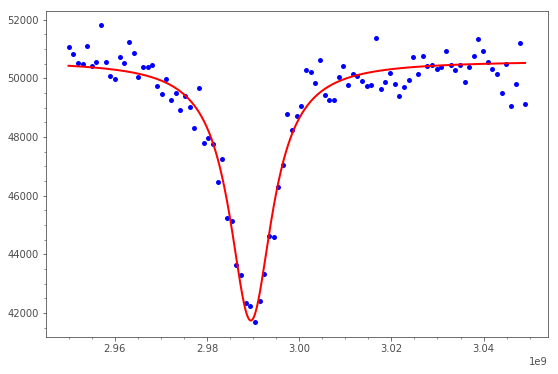

f0:  2989.5291733279796 MHz
Bias field:  3.9117561902849847 mT
FWHM:  0 MHz
Contrast:  0 %


In [7]:
mode = ''
gslac = False
left = False

#Analyse bias field
#Gathering data from dictonary
directory = 'C:\\Data\\2025\\03\\20250303\\ODMR\\'
podrm_path = directory + '20250303-1056-07_ooc_ODMR_ODMR_data_ch0_range0'+'.dat'
data_raw = np.loadtxt(podrm_path).T
var_list,data = (data_raw[0],data_raw[1])

gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.88e9 #in Hz, watch the Temperature

fwhm_bias = 0
contrast_bias = 0

#Determine fit

if mode == 'double':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_dip)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N15':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N15)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N14':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N14)
    lm,_ = fitlogic.make_lorentziandouble_model()

elif mode == 'gaussian_dip':
    fit = afm_scanner_logic._fitlogic.make_gaussian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_gaussian_dip)
    lm,_ = fitlogic.make_gaussian_model()
    fwhm_bias = fit.params['fwhm'].value*1e-6 #FWHM in MHz
    contrast_bias = fit.params['contrast'].value*-1
    
else:    
    fit = afm_scanner_logic._fitlogic.make_lorentzian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentzian_dip)
    lm,_ = fitlogic.make_lorentzian_model()

# print(fit.fit_report())
bias_res_freq = fit.params['center'].value

if gslac == True and left == True:
    b_field_bias = np.sqrt(abs(bias_res_freq + zero_field)**2 - e_field**2) / gyro_nv
else:
    b_field_bias = np.sqrt(abs(bias_res_freq - zero_field)**2 - e_field**2) / gyro_nv

#Plot Data an
plt.plot(var_list,data,'bo')

x = np.linspace(var_list[0],var_list[-1],10000, endpoint=True)
plt.plot(x, lm.eval(fit.params, x=x),'r-')

plt.show()

print('f0: ',bias_res_freq/1e6,'MHz')
print('Bias field: ',b_field_bias*1000,'mT')
print("FWHM: ",fwhm_bias,'MHz')
print("Contrast: ",contrast_bias,'%')

## Analyse seperate ESR Data

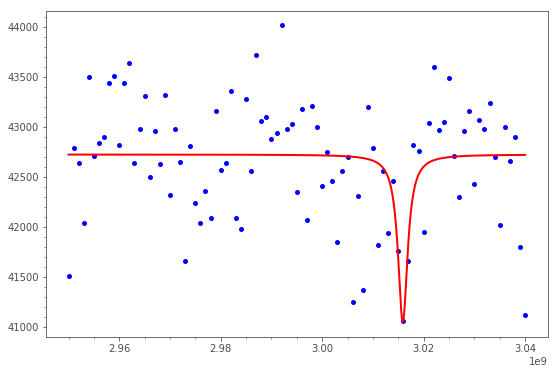

Resonance frequency: 3.0158956597541047 GHz
Bias field:  0.004853416419789451 T
FWHM:  2.2984859312869643 MHz
Contrast:  3.922324611746787 %


In [13]:
#Analyse single spectrum
#Gathering data from dictonary
i = 0
j = 0
gslac = False
left = False
mode = ''

tracking = qafm_data['Height(Dac)_fw']['params']['MW Tracking mode']
data = esr_data['esr_fw']['data'][i,j]

if not tracking:
    var_list = esr_data['esr_fw']['coord2_arr']
else:
    var_list = esr_data['esr_fw']['var_list'][i,j]

#Determine fit

gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.88e9 #in Hz, watch the Temperature

fwhm_bias = 0
contrast_bias = 0
b_field_single = 0
single_res_freq = 0


#Determine fit

if mode == 'double':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_dip)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N15':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N15)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N14':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N14)
    lm,_ = fitlogic.make_lorentziandouble_model()

elif mode == 'gaussian_dip':
    fit = afm_scanner_logic._fitlogic.make_gaussian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_gaussian_dip)
    lm,_ = fitlogic.make_gaussian_model()
    fwhm_bias = fit.params['fwhm'].value*1e-6 #FWHM in MHz
    contrast_bias = fit.params['contrast'].value*-1
    
else:    
    fit = afm_scanner_logic._fitlogic.make_lorentzian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentzian_dip)
    lm,_ = fitlogic.make_lorentzian_model()
    fwhm_bias = fit.params['fwhm'].value*1e-6 #FWHM in MHz
    contrast_bias = fit.params['contrast'].value*-1

# print(fit.fit_report())
single_res_freq = fit.params['center'].value

if gslac == True and left == True:
    b_field_single = np.sqrt(abs(single_res_freq + zero_field)**2 - e_field**2) / gyro_nv
else:
    b_field_single = np.sqrt(abs(single_res_freq - zero_field)**2 - e_field**2) / gyro_nv

#Plot Data an
plt.plot(var_list,data,'bo')

x = np.linspace(var_list[0],var_list[-1],10000, endpoint=True)
plt.plot(x, lm.eval(fit.params, x=x),'r-')

plt.show()

print('Resonance frequency:',single_res_freq/1e9,'GHz')
print('Bias field: ',b_field_single,'T')
print("FWHM: ",fwhm_bias,'MHz')
print("Contrast: ",contrast_bias,'%')

In [8]:
print(esr_data['esr_fw']['data'][0,0])
#print(tracking)

[17505.6718472  17272.35189498 17715.66004405 17732.32564788
 17755.65773962 17715.65997473 17705.66058641 17838.98624467
 17672.32921483 17569.00174153 17455.67481406 17795.65558129
 17808.98799211 17565.66844967 17315.68274867 17878.9840012
 17875.65101079 17615.66580419 17692.32786469 17612.33265347
 17495.6726242  18015.64289965 17405.6777595  17509.00521951
 17392.34505583 17352.3474429  17225.68792951 16872.37465139
 16662.38652408 16212.41212962 16295.74052166 16615.72232832
 16025.75617418 16552.39276653 17818.9875885  17179.02382333
 17592.33370506 17562.33540224 17492.3394429  17705.66039935
 17265.68568298 17295.6839547  17805.65499097 17502.33871878
 17522.33770902 17658.99656418 17622.3319055  17575.66807592
 17852.31888821 17722.32635219 17272.35189156 18292.2940153
 17582.33429085 17735.65878728 17399.01123485 17598.99997996
 17479.00690036 17682.32861165 17862.31837697 17608.99941021
 17882.3172669 ]


## Analyse full ESR Data

In [11]:
#Define the measured peak properties
mode = ''
gslac = False
left = False

#Analyse scan with Lorentzian fit and determine magnetic field
#Gathering data from dictonary
tracking = qafm_data['Height(Dac)_fw']['params']['MW Tracking mode']
data = esr_data['esr_fw']['data']

if not tracking:
    var_list = esr_data['esr_fw']['coord2_arr']

coord0_num = qafm_data['Height(Dac)_fw']['params']['coord0_num (#)']
coord1_num = qafm_data['Height(Dac)_fw']['params']['coord1_num (#)']
res_freq = np.zeros((coord1_num,coord0_num)) #in Hz from the fit
fwhm = np.zeros((coord1_num,coord0_num))
fwhm_err = np.zeros((coord1_num,coord0_num))
contrast = np.zeros((coord1_num,coord0_num))
contrast_err = np.zeros((coord1_num,coord0_num))
b_field = np.zeros((coord1_num,coord0_num))
error_array = np.zeros((coord1_num,coord0_num))

#Define parameters for magnetic field calculation
gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.87e9 #in Hz, watch the Temperature


for i in range(coord1_num):
    for j in range(coord0_num):
        
        if tracking:
            var_list = esr_data['esr_fw']['var_list'][i,j]
        #Determine fit
        try:
            if mode == 'double':
                fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_dip)
                res_freq[i,j] = fit.params['l0_center'].value + (fit.params['l1_center'].value-fit.params['l0_center'].value)/2
                
            elif mode == 'N15':
                fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N15)
                res_freq[i,j] = fit.params['l0_center'].value + (fit.params['l1_center'].value-fit.params['l0_center'].value)/2
                
            elif mode == 'N14':
                fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N14)
                res_freq[i,j] = fit.params['l0_center'].value
                
            elif mode == 'gaussian_dip':
                fit = afm_scanner_logic._fitlogic.make_gaussian_fit(var_list,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_gaussian_dip)
                res_freq[i,j] = fit.params['center'].value
                fwhm[i,j] = fit.params['fwhm'].value*1e-6 #FWHM in MHz
                fwhm_err[i,j] = fit.params['fwhm'].stderr*1e-6
                contrast[i,j] = fit.params['contrast'].value*-1
                contrast_err[i,j] = fit.params['contrast'].stderr*-1
                
            else:    
                fit = afm_scanner_logic._fitlogic.make_lorentzian_fit(var_list,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_lorentzian_dip)
                res_freq[i,j] = fit.params['center'].value
                fwhm[i,j] = fit.params['fwhm'].value*1e-6 #FWHM in MHz
                fwhm_err[i,j] = fit.params['fwhm'].stderr*1e-6
                contrast[i,j] = fit.params['contrast'].value*-1
                contrast_err[i,j] = fit.params['contrast'].stderr*-1
        
        except:
            error_array[i,j] = 1
        print(i,j)
            
if gslac == True and left == True:
    b_field = np.sqrt(abs(res_freq + zero_field)**2 - e_field**2) / gyro_nv
else:
    b_field = np.sqrt(abs(res_freq - zero_field)**2 - e_field**2) / gyro_nv

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
0 40
0 41
0 42
0 43
0 44
0 45
0 46
0 47
0 48
0 49
0 50
0 51
0 52
0 53
0 54
0 55
0 56
0 57
0 58
0 59
0 60
0 61
0 62
0 63
0 64
0 65
0 66
0 67
0 68
0 69
0 70
0 71
0 72
0 73
0 74
0 75
0 76
0 77
0 78
0 79
0 80
0 81
0 82
0 83
0 84
0 85
0 86
0 87
0 88
0 89
0 90
0 91
0 92
0 93
0 94
0 95
0 96
0 97
0 98
0 99
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
1 20
1 21
1 22
1 23
1 24
1 25
1 26
1 27
1 28
1 29
1 30
1 31
1 32
1 33
1 34
1 35
1 36
1 37
1 38
1 39
1 40
1 41
1 42
1 43
1 44
1 45
1 46
1 47
1 48
1 49
1 50
1 51
1 52
1 53
1 54
1 55
1 56
1 57
1 58
1 59
1 60
1 61
1 62
1 63
1 64
1 65
1 66
1 67
1 68
1 69
1 70
1 71
1 72
1 73
1 74
1 75
1 76
1 77
1 78
1 79
1 80
1 81
1 82
1 83
1 84
1 85
1 86
1 87
1 88
1 89
1 90
1 91
1 92
1 93
1 94
1 95
1 96
1 97
1 98
1 99
2 0
2 1
2 2
2 3
2 4


15 61
15 62
15 63
15 64
15 65
15 66
15 67
15 68
15 69
15 70
15 71
15 72
15 73
15 74
15 75
15 76
15 77
15 78
15 79
15 80
15 81
15 82
15 83
15 84
15 85
15 86
15 87
15 88
15 89
15 90
15 91
15 92
15 93
15 94
15 95
15 96
15 97
15 98
15 99
16 0
16 1
16 2
16 3
16 4
16 5
16 6
16 7
16 8
16 9
16 10
16 11
16 12
16 13
16 14
16 15
16 16
16 17
16 18
16 19
16 20
16 21
16 22
16 23
16 24
16 25
16 26
16 27
16 28
16 29
16 30
16 31
16 32
16 33
16 34
16 35
16 36
16 37
16 38
16 39
16 40
16 41
16 42
16 43
16 44
16 45
16 46
16 47
16 48
16 49
16 50
16 51
16 52
16 53
16 54
16 55
16 56
16 57
16 58
16 59
16 60
16 61
16 62
16 63
16 64
16 65
16 66
16 67
16 68
16 69
16 70
16 71
16 72
16 73
16 74
16 75
16 76
16 77
16 78
16 79
16 80
16 81
16 82
16 83
16 84
16 85
16 86
16 87
16 88
16 89
16 90
16 91
16 92
16 93
16 94
16 95
16 96
16 97
16 98
16 99
17 0
17 1
17 2
17 3
17 4
17 5
17 6
17 7
17 8
17 9
17 10
17 11
17 12
17 13
17 14
17 15
17 16
17 17
17 18
17 19
17 20
17 21
17 22
17 23
17 24
17 25
17 26
17 27
17 28
17 29
17 30


29 50
29 51
29 52
29 53
29 54
29 55
29 56
29 57
29 58
29 59
29 60
29 61
29 62
29 63
29 64
29 65
29 66
29 67
29 68
29 69
29 70
29 71
29 72
29 73
29 74
29 75
29 76
29 77
29 78
29 79
29 80
29 81
29 82
29 83
29 84
29 85
29 86
29 87
29 88
29 89
29 90
29 91
29 92
29 93
29 94
29 95
29 96
29 97
29 98
29 99
30 0
30 1
30 2
30 3
30 4
30 5
30 6
30 7
30 8
30 9
30 10
30 11
30 12
30 13
30 14
30 15
30 16
30 17
30 18
30 19
30 20
30 21
30 22
30 23
30 24
30 25
30 26
30 27
30 28
30 29
30 30
30 31
30 32
30 33
30 34
30 35
30 36
30 37
30 38
30 39
30 40
30 41
30 42
30 43
30 44
30 45
30 46
30 47
30 48
30 49
30 50
30 51
30 52
30 53
30 54
30 55
30 56
30 57
30 58
30 59
30 60
30 61
30 62
30 63
30 64
30 65
30 66
30 67
30 68
30 69
30 70
30 71
30 72
30 73
30 74
30 75
30 76
30 77
30 78
30 79
30 80
30 81
30 82
30 83
30 84
30 85
30 86
30 87
30 88
30 89
30 90
30 91
30 92
30 93
30 94
30 95
30 96
30 97
30 98
30 99
31 0
31 1
31 2
31 3
31 4
31 5
31 6
31 7
31 8
31 9
31 10
31 11
31 12
31 13
31 14
31 15
31 16
31 17
31 18
31 19


43 39
43 40
43 41
43 42
43 43
43 44
43 45
43 46
43 47
43 48
43 49
43 50
43 51
43 52
43 53
43 54
43 55
43 56
43 57
43 58
43 59
43 60
43 61
43 62
43 63
43 64
43 65
43 66
43 67
43 68
43 69
43 70
43 71
43 72
43 73
43 74
43 75
43 76
43 77
43 78
43 79
43 80
43 81
43 82
43 83
43 84
43 85
43 86
43 87
43 88
43 89
43 90
43 91
43 92
43 93
43 94
43 95
43 96
43 97
43 98
43 99
44 0
44 1
44 2
44 3
44 4
44 5
44 6
44 7
44 8
44 9
44 10
44 11
44 12
44 13
44 14
44 15
44 16
44 17
44 18
44 19
44 20
44 21
44 22
44 23
44 24
44 25
44 26
44 27
44 28
44 29
44 30
44 31
44 32
44 33
44 34
44 35
44 36
44 37
44 38
44 39
44 40
44 41
44 42
44 43
44 44
44 45
44 46
44 47
44 48
44 49
44 50
44 51
44 52
44 53
44 54
44 55
44 56
44 57
44 58
44 59
44 60
44 61
44 62
44 63
44 64
44 65
44 66
44 67
44 68
44 69
44 70
44 71
44 72
44 73
44 74
44 75
44 76
44 77
44 78
44 79
44 80
44 81
44 82
44 83
44 84
44 85
44 86
44 87
44 88
44 89
44 90
44 91
44 92
44 93
44 94
44 95
44 96
44 97
44 98
44 99
45 0
45 1
45 2
45 3
45 4
45 5
45 6
45 7
45 8

57 28
57 29
57 30
57 31
57 32
57 33
57 34
57 35
57 36
57 37
57 38
57 39
57 40
57 41
57 42
57 43
57 44
57 45
57 46
57 47
57 48
57 49
57 50
57 51
57 52
57 53
57 54
57 55
57 56
57 57
57 58
57 59
57 60
57 61
57 62
57 63
57 64
57 65
57 66
57 67
57 68
57 69
57 70
57 71
57 72
57 73
57 74
57 75
57 76
57 77
57 78
57 79
57 80
57 81
57 82
57 83
57 84
57 85
57 86
57 87
57 88
57 89
57 90
57 91
57 92
57 93
57 94
57 95
57 96
57 97
57 98
57 99
58 0
58 1
58 2
58 3
58 4
58 5
58 6
58 7
58 8
58 9
58 10
58 11
58 12
58 13
58 14
58 15
58 16
58 17
58 18
58 19
58 20
58 21
58 22
58 23
58 24
58 25
58 26
58 27
58 28
58 29
58 30
58 31
58 32
58 33
58 34
58 35
58 36
58 37
58 38
58 39
58 40
58 41
58 42
58 43
58 44
58 45
58 46
58 47
58 48
58 49
58 50
58 51
58 52
58 53
58 54
58 55
58 56
58 57
58 58
58 59
58 60
58 61
58 62
58 63
58 64
58 65
58 66
58 67
58 68
58 69
58 70
58 71
58 72
58 73
58 74
58 75
58 76
58 77
58 78
58 79
58 80
58 81
58 82
58 83
58 84
58 85
58 86
58 87
58 88
58 89
58 90
58 91
58 92
58 93
58 94
58 95
58

71 17
71 18
71 19
71 20
71 21
71 22
71 23
71 24
71 25
71 26
71 27
71 28
71 29
71 30
71 31
71 32
71 33
71 34
71 35
71 36
71 37
71 38
71 39
71 40
71 41
71 42
71 43
71 44
71 45
71 46
71 47
71 48
71 49
71 50
71 51
71 52
71 53
71 54
71 55
71 56
71 57
71 58
71 59
71 60
71 61
71 62
71 63
71 64
71 65
71 66
71 67
71 68
71 69
71 70
71 71
71 72
71 73
71 74
71 75
71 76
71 77
71 78
71 79
71 80
71 81
71 82
71 83
71 84
71 85
71 86
71 87
71 88
71 89
71 90
71 91
71 92
71 93
71 94
71 95
71 96
71 97
71 98
71 99
72 0
72 1
72 2
72 3
72 4
72 5
72 6
72 7
72 8
72 9
72 10
72 11
72 12
72 13
72 14
72 15
72 16
72 17
72 18
72 19
72 20
72 21
72 22
72 23
72 24
72 25
72 26
72 27
72 28
72 29
72 30
72 31
72 32
72 33
72 34
72 35
72 36
72 37
72 38
72 39
72 40
72 41
72 42
72 43
72 44
72 45
72 46
72 47
72 48
72 49
72 50
72 51
72 52
72 53
72 54
72 55
72 56
72 57
72 58
72 59
72 60
72 61
72 62
72 63
72 64
72 65
72 66
72 67
72 68
72 69
72 70
72 71
72 72
72 73
72 74
72 75
72 76
72 77
72 78
72 79
72 80
72 81
72 82
72 83
72 84
72

85 5
85 6
85 7
85 8
85 9
85 10
85 11
85 12
85 13
85 14
85 15
85 16
85 17
85 18
85 19
85 20
85 21
85 22
85 23
85 24
85 25
85 26
85 27
85 28
85 29
85 30
85 31
85 32
85 33
85 34
85 35
85 36
85 37
85 38
85 39
85 40
85 41
85 42
85 43
85 44
85 45
85 46
85 47
85 48
85 49
85 50
85 51
85 52
85 53
85 54
85 55
85 56
85 57
85 58
85 59
85 60
85 61
85 62
85 63
85 64
85 65
85 66
85 67
85 68
85 69
85 70
85 71
85 72
85 73
85 74
85 75
85 76
85 77
85 78
85 79
85 80
85 81
85 82
85 83
85 84
85 85
85 86
85 87
85 88
85 89
85 90
85 91
85 92
85 93
85 94
85 95
85 96
85 97
85 98
85 99
86 0
86 1
86 2
86 3
86 4
86 5
86 6
86 7
86 8
86 9
86 10
86 11
86 12
86 13
86 14
86 15
86 16
86 17
86 18
86 19
86 20
86 21
86 22
86 23
86 24
86 25
86 26
86 27
86 28
86 29
86 30
86 31
86 32
86 33
86 34
86 35
86 36
86 37
86 38
86 39
86 40
86 41
86 42
86 43
86 44
86 45
86 46
86 47
86 48
86 49
86 50
86 51
86 52
86 53
86 54
86 55
86 56
86 57
86 58
86 59
86 60
86 61
86 62
86 63
86 64
86 65
86 66
86 67
86 68
86 69
86 70
86 71
86 72
86 73
8

98 93
98 94
98 95
98 96
98 97
98 98
98 99
99 0
99 1
99 2
99 3
99 4
99 5
99 6
99 7
99 8
99 9
99 10
99 11
99 12
99 13
99 14
99 15
99 16
99 17
99 18
99 19
99 20
99 21
99 22
99 23
99 24
99 25
99 26
99 27
99 28
99 29
99 30
99 31
99 32
99 33
99 34
99 35
99 36
99 37
99 38
99 39
99 40
99 41
99 42
99 43
99 44
99 45
99 46
99 47
99 48
99 49
99 50
99 51
99 52
99 53
99 54
99 55
99 56
99 57
99 58
99 59
99 60
99 61
99 62
99 63
99 64
99 65
99 66
99 67
99 68
99 69
99 70
99 71
99 72
99 73
99 74
99 75
99 76
99 77
99 78
99 79
99 80
99 81
99 82
99 83
99 84
99 85
99 86
99 87
99 88
99 89
99 90
99 91
99 92
99 93
99 94
99 95
99 96
99 97
99 98
99 99


## Plot B field uncorrected - Bnv

In [ ]:
#Plot analysed Data from PODMR
x = (qafm_data['Height(Dac)_fw']['coord0_arr'])*10**6
y = (qafm_data['Height(Dac)_fw']['coord1_arr'])*10**6

plt.rcParams['figure.figsize'] = (5, 5)
fontsize = 12

low_centile = 0
high_centile = 100
data = (b_field)*10**3
im = plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.xlabel('X position (\u03BCm)',fontsize = fontsize)
plt.ylabel('Y position (\u03BCm)',fontsize = fontsize)

ax = plt.gca()
ax.set_aspect('equal')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label(label='$B_{NV}$ (mT)', size=fontsize)

plt.tight_layout()

plt.show()

## Plot corrected B field - Bnv - Bbias

In [ ]:
#Plot analysed Data from PODMR
x = (qafm_data['Height(Dac)_fw']['coord0_arr'])*10**6
y = (qafm_data['Height(Dac)_fw']['coord1_arr'])*10**6

#plt.rcParams['figure.figsize'] = (5, 5)
fontsize = 12

low_centile = 0
high_centile = 100
data = (b_field-b_field_bias)*10**3
im = plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.xlabel('X position (\u03BCm)',fontsize = fontsize)
plt.ylabel('Y position (\u03BCm)',fontsize = fontsize)

ax = plt.gca()
ax.set_aspect('equal')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label(label='$B_{NV}$ - $B_{bias}$ (mT)', size=fontsize)

plt.tight_layout()

plt.show()

## Plot complet dataset

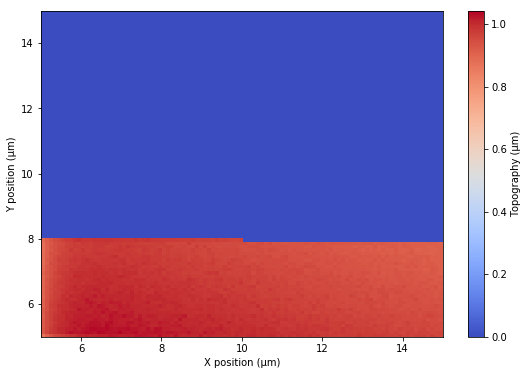

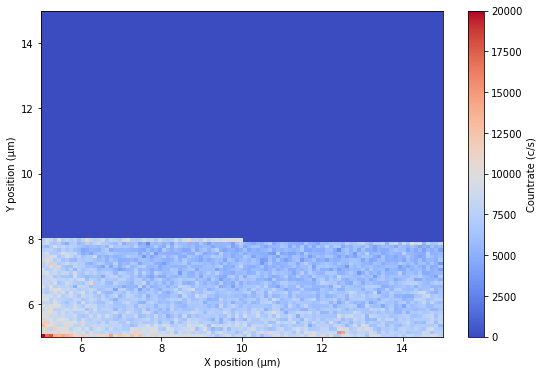

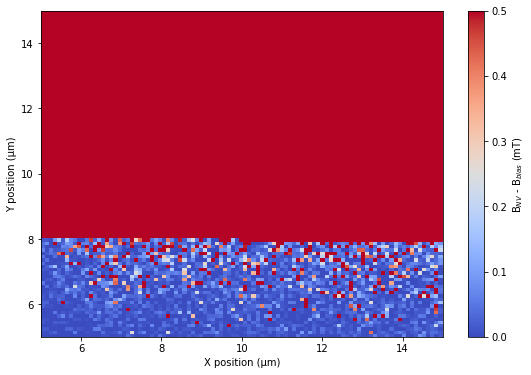

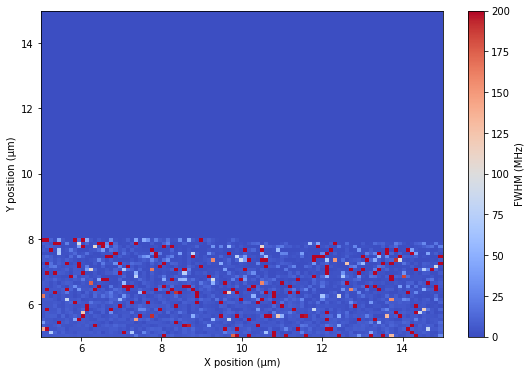

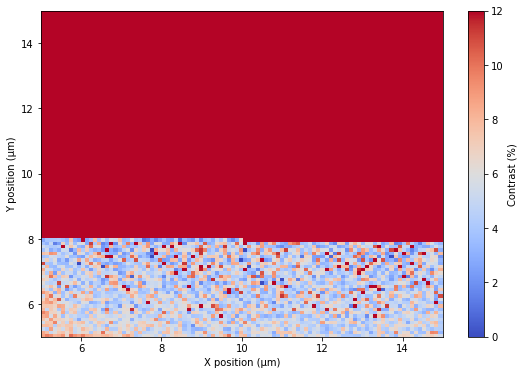

In [12]:
#Plot analysed Data from PODMR
x_gwy = qafm_data['Height(Dac)_fw']['coord0_arr']
y_gwy = qafm_data['Height(Dac)_fw']['coord1_arr']
x = x_gwy*10**6
y = y_gwy*10**6

#for gwyddion
dataobj = {}

## TOPO ##

low_centile = 0
high_centile = 100
data = qafm_data['Height(Dac)_fw']['data']*10**6
plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'Topography (\u03BCm)')
plt.show()
#for gwyddion
dataobj['Topography'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':qafm_data['Height(Dac)_fw']['data'],
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'm',
                            'nice_name': 'Topography'
    
                        }
## COUNTS ##

low_centile = 0
high_centile = 100
data = qafm_data['counts_fw']['data']
plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'Countrate (c/s)')
plt.show()
#for gwyddion
dataobj['Fluorescence'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':qafm_data['counts_fw']['data'],
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'c/s',
                            'nice_name': 'Fluorescence'
    
                        }
## RES FREQ ##

# low_centile = 0.75
# high_centile = 99.8
# data = res_freq/10**9
# plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
# plt.xlabel('X position (\u03BCm)')
# plt.ylabel('Y position (\u03BCm)')
# plt.colorbar(label = 'Frequency (GHz)')
# plt.show()


## BFIELD CORR mT ##

low_centile = 0
high_centile = 100
data = b_field*10**3 -b_field_bias*10**3 # b_field_bias is found earlier from OOC fit. In tesla
#plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =0, vmax = 0.5)
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'B$_{NV}$ - B$_{bias}$ (mT)')
plt.show()
#for gwyddion
dataobj['Stray Field'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':b_field-b_field_bias,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                        
                            'si_units': 'T',
                            'nice_name': 'Stray Field: B_NV - B_bias'
    
                        }

## FWHM ##

low_centile = 0
high_centile = 100
data = fwhm # b_field_bias is found earlier from OOC fit. In tesla
#plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =0, vmax = 200)
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'FWHM (MHz)')
plt.show()
#for gwyddion
dataobj['Linewidth'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':data*1e6,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                        
                            'si_units': 'Hz',
                            'nice_name': 'Linewidth'
    
                        }


low_centile = 0
high_centile = 100
data = contrast
#plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =0, vmax = 12)
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'Contrast (%)')
plt.show()
#for gwyddion
dataobj['Contrast'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':data,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                        
                            'si_units': '',
                            'nice_name': 'Contrast'
    
                        }


## Save to new gwyddion file - data defined in previous cell and pickel

In [ ]:
"""save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """
from logic import gwyfile as gwy
save_obj_to_gwyddion(dataobj=dataobj,filename=filepath+'QAFM_jupyter_corrected.gwy')

#Save calculated B field to pickel
esr_array = esr_data
esr_array['esr_fw']['b_field'] = b_field
esr_array['esr_fw']['b_field_bias'] = b_field_bias
with open(filepath+'esr_array_bfield_T.pickle', 'wb') as f:
    pickle.dump(esr_array, f)